In [1]:
import torch
from torchvision.datasets import CIFAR100
import torchvision.models as models

In [2]:
# import sys
# import os
# sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

### Utils

In [3]:
from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizer
from torchvision.datasets import CIFAR100
from torchvision import transforms
import torch
import pandas as pd
import numpy as np
import random

class DatasetPipeline:
    def __init__(self, seed=42):
        self.seed = seed
        self.tokenizer = None
        self.task_type = None

    def set_seed(self):
        random.seed(self.seed)
        np.random.seed(self.seed)
        torch.manual_seed(self.seed)

    def prepare_nlp(self, csv_path, tokenizer_name="distilbert-base-uncased",
                    train_size=2000, test_size=250, val_size=250):
        self.task_type = "nlp"
        self.set_seed()

        df = pd.read_csv(csv_path, encoding='latin-1')
        df['sentiment'] = df['sentiment'].astype('category')

        df_train, df_temp = train_test_split(
            df, train_size=train_size, test_size=test_size + val_size,
            stratify=df['sentiment'], random_state=self.seed
        )
        df_test, df_val = train_test_split(
            df_temp, train_size=test_size, test_size=val_size,
            stratify=df_temp['sentiment'], random_state=self.seed
        )

        df_train.reset_index(drop=True, inplace=True)
        df_val.reset_index(drop=True, inplace=True)
        df_test.reset_index(drop=True, inplace=True)

        label_map = {'negative': 0, 'positive': 1}
        for df_split in [df_train, df_val, df_test]:
            df_split.rename(columns={"sentiment": "label"}, inplace=True)
            df_split["label"] = df_split["label"].map(label_map)

        self.tokenizer = DistilBertTokenizer.from_pretrained(tokenizer_name)

        def preprocess_function(examples):
            return self.tokenizer(
                examples["review"],
                truncation=True,
                padding="max_length",
                max_length=512
            )

        train_ds = Dataset.from_pandas(df_train[["review", "label"]])
        val_ds = Dataset.from_pandas(df_val[["review", "label"]])
        test_ds = Dataset.from_pandas(df_test[["review", "label"]])

        train_ds = train_ds.map(preprocess_function, batched=True)
        val_ds = val_ds.map(preprocess_function, batched=True)
        test_ds = test_ds.map(preprocess_function, batched=True)

        train_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
        val_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
        test_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

        return train_ds, val_ds, test_ds

    def prepare_vision(self, dataset_class=CIFAR100, root="/data"):
        self.task_type = "vision"
        self.set_seed()

        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

        full_train = dataset_class(root=root, train=True, transform=transform, download=True)
        test_dataset = dataset_class(root=root, train=False, transform=transform, download=True)

        train_size = int(0.8 * len(full_train))
        val_size = len(full_train) - train_size
        generator = torch.Generator().manual_seed(self.seed)
        train_dataset, val_dataset = torch.utils.data.random_split(
            full_train, [train_size, val_size], generator=generator
        )

        return train_dataset, val_dataset, test_dataset


In [4]:
from torch.utils.data import DataLoader
from transformers import default_data_collator

class DataLoaderFactory:
    def __init__(self, task_type: str = "nlp", batch_size=32, num_workers=0):
        if task_type not in ["nlp", "vision"]:
            raise ValueError("task_type must be 'nlp' or 'vision'")
        self.task_type = task_type
        self.batch_size = batch_size
        self.num_workers = num_workers

    def _get_collate_fn(self):
        if self.task_type == "nlp":
            return default_data_collator
        else:
            return None

    def create_loaders(self, train_ds, val_ds, test_ds):
        collate_fn = self._get_collate_fn()

        train_loader = DataLoader(
            train_ds,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            collate_fn=collate_fn
        )
        val_loader = DataLoader(
            val_ds,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            collate_fn=collate_fn
        )
        test_loader = DataLoader(
            test_ds,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            collate_fn=collate_fn
        )

        return train_loader, val_loader, test_loader


In [5]:
! pip install -q optuna torch-adopt

In [6]:
from tabulate import tabulate
from tqdm import tqdm
from typing import Callable, Literal

import gc
import optuna
import torch
import torch.optim as optim
from adopt import ADOPT
from optuna.trial import Trial
from torch import nn
from torch.utils.data import DataLoader, Dataset


def get_optimizer(
    optimizer_name: str,
    model: nn.Module,
    optimizer_params: dict[str, object] = None
) -> optim.Optimizer:
    if optimizer_name == "SGD":
        return optim.SGD(model.parameters(), **optimizer_params)
    elif optimizer_name == "Adam":
        return optim.Adam(
            model.parameters(), **optimizer_params,
        )
    elif optimizer_name == "AdamW":
        return optim.AdamW(
            model.parameters(),**optimizer_params)
    elif optimizer_name == "RMSprop":
        return optim.RMSprop(model.parameters(),**optimizer_params)
    elif optimizer_name == "ADOPT":
        return ADOPT(model.parameters(),**optimizer_params)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

def objective(
    trial: optuna.Trial,
    train_dataset: Dataset,
    val_dataset: Dataset,
    model_fn: Callable,
    optimizer_name: Literal["SGD", "Adam", "AdamW", "RMSprop", "ADOPT"],
    task_type: str = "classification",
    num_classes: int = 2,
    device: str = "cuda"
):

    if optimizer_name not in ["SGD", "Adam", "AdamW", "RMSprop", "ADOPT"]:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")
    if train_dataset is None or val_dataset is None:
        raise ValueError("train_dataset and val_dataset must be provided")
    if model_fn is None:
        raise ValueError("You must provide model_fn")

    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    # batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    # num_epochs = trial.suggest_int("num_epochs", 1, 10)
    optimizer_params = {"lr": learning_rate}

    if hasattr(train_dataset, 'set_format'):
        train_dataset.set_format(None)
        val_dataset.set_format(None)

    class HuggingFaceDatasetWrapper(torch.utils.data.Dataset):
        def __init__(self, dataset):
            self.dataset = dataset
        def __getitem__(self, idx):
            item = self.dataset[idx]
            return {k: torch.tensor(v) if isinstance(v, (list, int)) and not isinstance(v, str) else v
                    for k, v in item.items()}
        def __len__(self):
            return len(self.dataset)

    if task_type == "nlp":
        wrapped_train = HuggingFaceDatasetWrapper(train_dataset)
        wrapped_val = HuggingFaceDatasetWrapper(val_dataset)
    elif task_type == "vision":
        wrapped_train = train_dataset
        wrapped_val = val_dataset

    loader_factory = DataLoaderFactory(task_type=task_type, batch_size=batch_size)
    train_loader, val_loader, _ = loader_factory.create_loaders(
        train_ds=wrapped_train,
        val_ds=wrapped_val,
        test_ds=None
    )

    model = model_fn(num_classes=num_classes).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = get_optimizer(optimizer_name, model, optimizer_params=optimizer_params)

    try:
        for epoch in range(num_epochs):
            model.train()
            progress_bar = tqdm(train_loader, desc=f"Trial {trial.number} | Epoka {epoch+1}/{num_epochs}", leave=False)

            for batch in progress_bar:
                try:
                    if task_type == "vision":
                        inputs, labels = batch
                        inputs, labels = inputs.to(device), labels.to(device)
                        outputs = model(inputs)

                    elif task_type == "nlp":
                        input_ids = batch['input_ids'].to(device)
                        attention_mask = batch['attention_mask'].to(device)
                        labels = batch['label'].to(device)
                        outputs = model(input_ids, attention_mask=attention_mask).logits

                    else:
                        raise ValueError(f"Unsupported task type: {task_type}")

                    optimizer.zero_grad()
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()

                    progress_bar.set_postfix(loss=loss.item())

                except RuntimeError as e:
                    if "out of memory" in str(e).lower():
                        torch.cuda.empty_cache()
                        gc.collect()
                        raise optuna.exceptions.TrialPruned()
                    else:
                        raise

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in val_loader:
                if task_type == "vision":
                    inputs, labels = batch
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)

                elif task_type == "nlp":
                    input_ids = batch['input_ids'].to(device)
                    attention_mask = batch['attention_mask'].to(device)
                    labels = batch['label'].to(device)
                    outputs = model(input_ids, attention_mask=attention_mask).logits

                else:
                    raise ValueError(f"Unsupported task type: {task_type}")

                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = correct / total

    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            torch.cuda.empty_cache()
            gc.collect()
            raise optuna.exceptions.TrialPruned()
        else:
            raise

    torch.cuda.empty_cache()
    gc.collect()

    return accuracy

def tune_optimizers_with_optuna(optimizers,
                                n_trials=5,
                                train_dataset=None,
                                val_dataset=None,
                                num_classes=2,
                                task_type: str = "classification",
                                model_fn=None):

    if train_dataset is None or val_dataset is None:
        raise ValueError("train_dataset and val_dataset must be provided")

    best_hyperparams = {}

    for optimizer_name in optimizers:
        print(f"Hyperparameter tuning for: {optimizer_name}")

        def wrapped_objective(trial):
            torch.cuda.empty_cache()
            gc.collect()
            return objective(trial,
                             optimizer_name,
                             train_dataset,
                             val_dataset,
                             num_classes,
                             task_type,
                             model_fn)

        study = optuna.create_study(direction="maximize")
        study.optimize(wrapped_objective, n_trials=n_trials)

        best_hyperparams[optimizer_name] = {
            "params": study.best_params,
            "accuracy": study.best_value
        }

        print(f"Best hyperparameters for {optimizer_name}: {study.best_params}")

    return best_hyperparams

def print_hyperparams_table(hyperparams):
    headers = ["Optimizer", "Best Accuracy", "Best Hyperparameters"]
    table = []

    for optimizer, params in hyperparams.items():
        table.append([
            optimizer,
            f"{params['accuracy']:.4f}",
            str(params['params'])
        ])

    print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

### Param Tuning

In [7]:
batch_size = 32
num_epochs = 5
learning_rate = 1e-3
seed = 42
num_classes = 100

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
pipeline = DatasetPipeline(
    seed=seed
)
train_ds, val_ds, test_ds = pipeline.prepare_vision(CIFAR100)
loader_factory = DataLoaderFactory(task_type="vision", batch_size=batch_size)
train_loader, val_loader, test_loader = loader_factory.create_loaders(
    train_ds=train_ds,
    val_ds=val_ds,
    test_ds=test_ds
)

## Optuna

In [9]:
optimizers = ["Adam", "SGD", "RMSprop"]
best_params = tune_optimizers_with_optuna(optimizers,
                                          n_trials=3,
                                          train_dataset=train_ds,
                                          val_dataset=val_ds,
                                          num_classes=num_classes,
                                          task_type="vision",
                                          model_fn=lambda num_classes: models.resnet18(
                                              num_classes=num_classes
                                          ))

print("\n📋 Podsumowanie:")
for opt, params in best_params.items():
    print(f"{opt}: {params}")

[I 2025-05-24 16:23:34,136] A new study created in memory with name: no-name-620ff141-0dda-46cd-b392-ba76b5daaff4


Hyperparameter tuning for: Adam


[I 2025-05-24 16:24:37,364] Trial 0 finished with value: 0.0238 and parameters: {'learning_rate': 0.01960926186244488, 'batch_size': 16, 'num_epochs': 1}. Best is trial 0 with value: 0.0238.
[I 2025-05-24 16:29:01,934] Trial 1 finished with value: 0.4246 and parameters: {'learning_rate': 0.001498661002238118, 'batch_size': 32, 'num_epochs': 8}. Best is trial 1 with value: 0.4246.
[I 2025-05-24 16:37:17,474] Trial 2 finished with value: 0.3297 and parameters: {'learning_rate': 3.8999898661566044e-05, 'batch_size': 8, 'num_epochs': 6}. Best is trial 1 with value: 0.4246.
[I 2025-05-24 16:37:17,475] A new study created in memory with name: no-name-62caa064-b865-402e-a79d-53bf318f01bd


Best hyperparameters for Adam: {'learning_rate': 0.001498661002238118, 'batch_size': 32, 'num_epochs': 8}
Hyperparameter tuning for: SGD


[I 2025-05-24 16:44:46,820] Trial 0 finished with value: 0.4028 and parameters: {'learning_rate': 0.051722979436581336, 'batch_size': 16, 'num_epochs': 10}. Best is trial 0 with value: 0.4028.
[I 2025-05-24 16:51:23,008] Trial 1 finished with value: 0.3264 and parameters: {'learning_rate': 0.0019499089185571305, 'batch_size': 16, 'num_epochs': 9}. Best is trial 0 with value: 0.4028.
[I 2025-05-24 16:53:19,872] Trial 2 finished with value: 0.3419 and parameters: {'learning_rate': 0.02404153723735208, 'batch_size': 32, 'num_epochs': 4}. Best is trial 0 with value: 0.4028.
[I 2025-05-24 16:53:19,874] A new study created in memory with name: no-name-32b19e2b-2627-4dd9-887a-39176e21d060


Best hyperparameters for SGD: {'learning_rate': 0.051722979436581336, 'batch_size': 16, 'num_epochs': 10}
Hyperparameter tuning for: RMSprop


[I 2025-05-24 17:06:02,374] Trial 0 finished with value: 0.2817 and parameters: {'learning_rate': 1.125019239779517e-05, 'batch_size': 8, 'num_epochs': 10}. Best is trial 0 with value: 0.2817.
[I 2025-05-24 17:13:40,778] Trial 1 finished with value: 0.269 and parameters: {'learning_rate': 0.0007207194063056192, 'batch_size': 8, 'num_epochs': 6}. Best is trial 0 with value: 0.2817.
[I 2025-05-24 17:17:15,891] Trial 2 finished with value: 0.218 and parameters: {'learning_rate': 1.0747238429682038e-05, 'batch_size': 32, 'num_epochs': 7}. Best is trial 0 with value: 0.2817.


Best hyperparameters for RMSprop: {'learning_rate': 1.125019239779517e-05, 'batch_size': 8, 'num_epochs': 10}

📋 Podsumowanie:
Adam: {'params': {'learning_rate': 0.001498661002238118, 'batch_size': 32, 'num_epochs': 8}, 'accuracy': 0.4246}
SGD: {'params': {'learning_rate': 0.051722979436581336, 'batch_size': 16, 'num_epochs': 10}, 'accuracy': 0.4028}
RMSprop: {'params': {'learning_rate': 1.125019239779517e-05, 'batch_size': 8, 'num_epochs': 10}, 'accuracy': 0.2817}


In [10]:
print_hyperparams_table(best_params)

╒═════════════╤═════════════════╤═════════════════════════════════════════════════════════════════════════════╕
│ Optimizer   │   Best Accuracy │ Best Hyperparameters                                                        │
╞═════════════╪═════════════════╪═════════════════════════════════════════════════════════════════════════════╡
│ Adam        │          0.4246 │ {'learning_rate': 0.001498661002238118, 'batch_size': 32, 'num_epochs': 8}  │
├─────────────┼─────────────────┼─────────────────────────────────────────────────────────────────────────────┤
│ SGD         │          0.4028 │ {'learning_rate': 0.051722979436581336, 'batch_size': 16, 'num_epochs': 10} │
├─────────────┼─────────────────┼─────────────────────────────────────────────────────────────────────────────┤
│ RMSprop     │          0.2817 │ {'learning_rate': 1.125019239779517e-05, 'batch_size': 8, 'num_epochs': 10} │
╘═════════════╧═════════════════╧═══════════════════════════════════════════════════════════════════════

## Training

In [ ]:
from train_compare import compare_optimizers_with_metrics

In [ ]:
import neptune

run = neptune.init_run(
    project="notatkipw/ZZSN",
    api_token="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiIyMzQ0ZWY0Zi0wZmZhLTRjZGItODRlNS02YWE5NmY5Yjc3OWIifQ==",            # Replace with your Neptune API token
)

[neptune] [warning] NeptuneWarning: By default, these monitoring options are disabled in interactive sessions: 'capture_stdout', 'capture_stderr', 'capture_traceback', 'capture_hardware_metrics'. You can set them to 'True' when initializing the run and the monitoring will continue until you call run.stop() or the kernel stops. NOTE: To track the source files, pass their paths to the 'source_code' argument. For help, see: https://docs-legacy.neptune.ai/logging/source_code/


[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/notatkipw/ZZSN/e/ZZSN-37


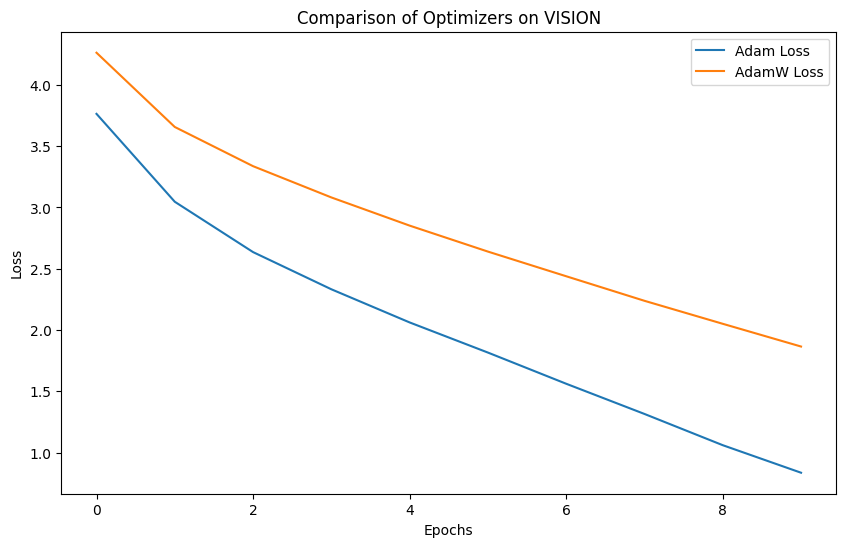

Optimizer: Adam
Accuracy: 0.4296
Precision: 0.4494
Recall: 0.4296
F1 Score: 0.4282
------------------------------
Optimizer: AdamW
Accuracy: 0.2685
Precision: 0.2674
Recall: 0.2685
F1 Score: 0.2650
------------------------------
[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 5 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 5 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/notatkipw/ZZSN/e/ZZSN-37/metadata


In [ ]:
# optimizers = ["ADOPT", "SGD", "Adam", "AdamW", "RMSprop"]
optimizers = {
    "Adam": {"lr": 1e-3},
    "AdamW": {"lr": 2e-5, "weight_decay": 0.01}
}

compare_optimizers_with_metrics(
    optimizers=optimizers,
    run=run,
    model_fn=lambda num_classes: models.resnet18(num_classes=num_classes),
    train_loader=train_loader,
    test_loader=test_loader,
    task_type="vision",
    num_classes=num_classes,
    epochs=10,
    device=device
)

run.stop()